In [ ]:
import sys
sys.path.append('./utils')
from utils import load_data, scale_data, load_and_prepare_kfold_data, evaluate_model, plot_residuals, save_results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import NuSVR
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.model_selection import cross_val_score,train_test_split,GridSearchCV,KFold
from sklearn.pipeline import Pipeline
import seaborn as sns

In [ ]:
X_train_cv, X_val_cv, X_test_cv, y_train_cv, y_val_cv, y_test_cv = load_data()
X_train_cv, X_val_cv, X_test_cv, scaler = scale_data(X_train_cv, X_val_cv, X_test_cv)

       cement    slag  fly_ash  ...  coarse_agg  fine_agg     age
count  603.00  603.00   603.00  ...      603.00    603.00  603.00
mean     0.05    0.37     0.45  ...        0.04     -0.06    0.44
std      0.68    0.64     0.54  ...        0.80      0.81    1.45
min     -1.14   -0.14     0.00  ...       -1.72     -1.83   -0.59
25%     -0.51   -0.14     0.00  ...       -0.37     -0.51   -0.38
50%      0.00    0.00     0.00  ...        0.00      0.00    0.00
75%      0.49    0.86     1.00  ...        0.63      0.49    0.62
max      1.71    2.55     1.69  ...        1.72      2.09    7.41

[8 rows x 8 columns]


Best C: 1000, Best nu: 0.6, Val RMSE: 2.9097


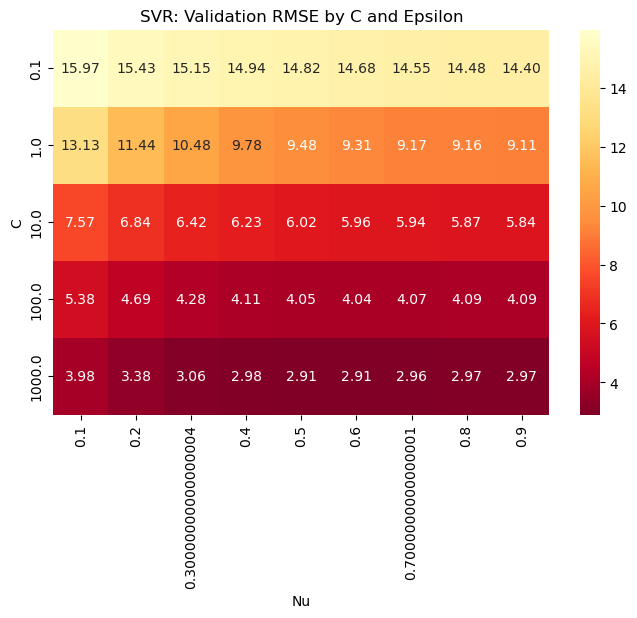

Train RMSE: 2.909714437104613
Train R²  : 0.9675337452874846
Val RMSE  : 5.399780019247747
Val R²    : 0.8720949826611984


In [ ]:
C_values       = [0.1, 1, 10, 100, 1000]
nu_values = np.arange(0.1, 1.0, 0.1)

best_val_rmse = float('inf')
best_C        = None
best_nu  = None
results       = []

for c in C_values:
    for nu in nu_values:
        svr_cv = NuSVR(kernel='rbf', C=c, nu=nu)
        svr_cv.fit(X_train_cv, y_train_cv)      
        RMSE = np.sqrt(mean_squared_error(y_train_cv, svr_cv.predict(X_train_cv)))
        results.append({'C': c, 'Nu': nu, 'val_rmse': RMSE})
        
        if RMSE < best_val_rmse:
            best_val_rmse = RMSE 
            best_C = c
            best_nu = nu
            
print(f"Best C: {best_C}, Best nu: {best_nu}, Val RMSE: {best_val_rmse:.4f}")

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='C', columns='Nu', values='val_rmse')

plt.figure(figsize=(8, 5))

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r')
plt.title('NuSVR: Validation RMSE by C and Nu')
plt.show()

nusvr_cv = NuSVR(kernel='rbf', C=best_C, nu=best_nu)
nusvr_cv.fit(X_train_cv, y_train_cv)

y_pred_train_cv = nusvr_cv.predict(X_train_cv)
y_pred_val_cv   = nusvr_cv.predict(X_val_cv)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_cv, y_pred_train_cv)))
print("Train R²  :", r2_score(y_train_cv, y_pred_train_cv))
print("Val RMSE  :", np.sqrt(mean_squared_error(y_val_cv, y_pred_val_cv)))
print("Val R²    :", r2_score(y_val_cv, y_pred_val_cv))

## K-Fold Validation


In [ ]:
X_train_kf, X_test_kf, y_train_kf, y_test_kf = load_and_prepare_kfold_data(r"../Datasets/uci_concrete_data.csv")

In [ ]:
param_grid = {
    'svr__C':       [0.1, 1, 10, 100, 1000],
    'svr__nu': np.arange(0.1, 1.0, 0.1),
    'svr__kernel':  ['rbf', 'linear']
}

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svr', NuSVR())
])

grid_search = GridSearchCV(pipeline, param_grid, 
                           cv=KFold(n_splits=3, shuffle=True, random_state=42),
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)
grid_search.fit(X_train_kf, y_train_kf)

print("Best params:", grid_search.best_params_)
print("Best RMSE:",  -grid_search.best_score_)

# Training performance
y_pred_train_kf = grid_search.predict(X_train_kf)
print("\nTrain RMSE:", np.sqrt(mean_squared_error(y_train_kf, y_pred_train_kf)))
print("Train R²  :", r2_score(y_train_kf, y_pred_train_kf))

Best params: {'svr__C': 1000, 'svr__kernel': 'rbf', 'svr__nu': np.float64(0.4)}
Best RMSE: 5.664113844424512


In [ ]:
# Testing performance
y_pred_kf = grid_search.predict(X_test_kf)
results = evaluate_model('NuSVR', y_train_kf, y_pred_train_kf, y_test_kf, y_pred_kf)
plot_residuals('NuSVR', y_test_kf, y_pred_kf)
save_results(results, 'nuSVR_results.csv')


Train RMSE: 2.8958069268600415
Train R²  : 0.9668447280195294

Test RMSE: 6.09195973815792
Test R²  : 0.8811572643825839


In [ ]:
results = evaluate_model('NuSVR', y_train_kf, y_pred_train, y_test, y_pred_test)

MAE  : 3.8936
RMSE : 6.0920
R    : 0.9387
R²   : 0.8812
